# High Risk Project

## Dataset
Willian Oliveira. (2025). Chinese medicine Individual [Data set]. Kaggle. https://doi.org/10.34740/KAGGLE/DSV/11301958


```
 @misc{

    willian_oliveira_2025,
	  title={Chinese medicine Individual},
	  url={https://www.kaggle.com/dsv/11301958},
	  DOI={10.34740/KAGGLE/DSV/11301958},
	  publisher={Kaggle},
	  author={willian oliveira},
	  year={2025}

 }
```





# Recommendation
* Run this on A100 Google Colab GPU

In [ ]:
import kagglehub
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download("willianoliveiragibin/chinese-medicine-individual")
print("Path to dataset files:", path)

# List all files in the dataset
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

Using Colab cache for faster access to the 'chinese-medicine-individual' dataset.
Path to dataset files: /kaggle/input/chinese-medicine-individual
/kaggle/input/chinese-medicine-individual/Chinese medicine Individual new.csv


In [ ]:
# Load the main dataset (adjust filename based on what you see)
import glob

# Find all CSV files
csv_files = glob.glob(f"{path}/*.csv")
print("CSV files found:", csv_files)

# Load the first one (or the main one you identify)
df = pd.read_csv(csv_files[0])  # Adjust index if needed

# Explore the structure
print("\nDataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

CSV files found: ['/kaggle/input/chinese-medicine-individual/Chinese medicine Individual new.csv']

Dataset shape: (8975, 11)

Column names: ['id', 'SimplifiedName', 'TraditionalName', 'PinyinName', 'CategoryName', 'EnglishName_1', 'EnglishName_2', 'EnglishName_3', 'EnglishInterpretation', 'sort_id', 'CategoryCode']

First few rows:
   id SimplifiedName TraditionalName     PinyinName CategoryName  \
0   1             诊断              診斷      zhěn duàn        中医诊断学   
1   2            诊断学             診斷學  zhěn duàn xué        中医诊断学   
2   3             中恶              中惡        zhōng è        中医内科学   
3   4             中寒              中寒      zhōng hán        中医内科学   
4   5            百合病             百合病    bǎi hé bìng        中医内科学   

  EnglishName_1                          EnglishName_2         EnglishName_3  \
0     diagnosis                                      0                     0   
1   DIAGNOSTICS                                      0                     0   
2             0 

In [ ]:
# Clean the dataset - handle those '0' values
df_clean = df.copy()

# Replace '0' strings with empty strings for better handling
columns_to_clean = ['EnglishName_1', 'EnglishName_2', 'EnglishName_3', 'EnglishInterpretation']

for col in columns_to_clean:
    df_clean[col] = df_clean[col].replace('0', '')

# Create a combined English name (merge all three English names)
def combine_english_names(row):
    names = []
    for col in ['EnglishName_1', 'EnglishName_2', 'EnglishName_3']:
        if row[col] and row[col].strip():
            names.append(row[col].strip())
    return ' | '.join(set(names)) if names else ''  # Remove duplicates

df_clean['combined_english'] = df_clean.apply(combine_english_names, axis=1)

# Create a rich search text that combines all searchable info
def create_search_text(row):
    parts = []

    # Chinese terms
    if row['SimplifiedName']:
        parts.append(f"Chinese: {row['SimplifiedName']}")

    # Pinyin
    if row['PinyinName']:
        parts.append(f"Pinyin: {row['PinyinName']}")

    # English names
    if row['combined_english']:
        parts.append(f"English: {row['combined_english']}")

    # Category
    if row['CategoryName']:
        parts.append(f"Category: {row['CategoryName']}")

    # Interpretation
    if row['EnglishInterpretation']:
        parts.append(f"Meaning: {row['EnglishInterpretation']}")

    return " | ".join(parts)

df_clean['search_text'] = df_clean.apply(create_search_text, axis=1)

# Remove rows where there's no useful English information
df_clean = df_clean[df_clean['combined_english'] != '']

print(f"✅ Cleaned dataset: {len(df_clean)} terms with English translations")
print(f"   (Removed {len(df) - len(df_clean)} terms without English names)")

# Show a sample
print("\n📋 Sample cleaned entry:")
sample = df_clean[df_clean['SimplifiedName'] == '百合病'].iloc[0]
print(f"  Chinese: {sample['SimplifiedName']}")
print(f"  Pinyin: {sample['PinyinName']}")
print(f"  English: {sample['combined_english']}")
print(f"  Category: {sample['CategoryName']}")
print(f"  Interpretation: {sample['EnglishInterpretation'][:100]}...")
print(f"\n  Search Text Preview:\n  {sample['search_text'][:200]}...")

✅ Cleaned dataset: 8971 terms with English translations
   (Removed 4 terms without English names)

📋 Sample cleaned entry:
  Chinese: 百合病
  Pinyin: bǎi hé bìng
  English: lily disease
  Category: 中医内科学
  Interpretation: ancient term for neurosis characterized by mental strain, listlessness, sleeplessness, anorexia, pse...

  Search Text Preview:
  Chinese: 百合病 | Pinyin: bǎi hé bìng | English: lily disease | Category: 中医内科学 | Meaning: ancient term for neurosis characterized by mental strain, listlessness, sleeplessness, anorexia, pseudo heat and...


In [ ]:
df

,id,SimplifiedName,TraditionalName,PinyinName,CategoryName,EnglishName_1,EnglishName_2,EnglishName_3,EnglishInterpretation,sort_id,CategoryCode
0,1,诊断,診斷,zhěn duàn,中医诊断学,diagnosis,0,0,determination of the nature of a diseased cond...,12,3.601.014
1,2,诊断学,診斷學,zhěn duàn xué,中医诊断学,DIAGNOSTICS,0,0,0,12,3.611.014
2,3,中恶,中惡,zhōng è,中医内科学,0,name of an extra point,extra point of EX-CA,0,46,3.601.017
3,4,中寒,中寒,zhōng hán,中医内科学,cold stroke,center cold (cold in the middle jiao),cold in the middle,attack of cold directly to the stomach and int...,46,3.611.017
4,5,百合病,百合病,bǎi hé bìng,中医内科学,lily disease,lily disease,lily disease,ancient term for neurosis characterized by men...,46,3.621.017
...,...,...,...,...,...,...,...,...,...,...,...
8970,8971,格致槁,格致槁,gé zhì gǎo,中医文献学,Draft on an Inquiry into the Properties of Things,0,0,0,40,5.081.067
8971,8972,血证论,血證論,xuè zhèng lùn,中医文献学,Treatise on Blood Patterns/Syndromes,0,0,0,40,5.091.067
8972,8973,鱼樵问荅医术,魚樵問荅醫術,yú qiáo wèn dá yī shù,中医文献学,Dialogue of Fisherman and Woodman about Medici...,0,0,0,40,5.101.067
8973,8974,东医寿世保元,東醫壽世保元,dōng yī shòu shì bǎo yuán,中医文献学,Longevity and Life Preservation in Eastern,0,0,0,40,5.111.067


In [ ]:
df_clean

,id,SimplifiedName,TraditionalName,PinyinName,CategoryName,EnglishName_1,EnglishName_2,EnglishName_3,EnglishInterpretation,sort_id,CategoryCode,combined_english,search_text
0,1,诊断,診斷,zhěn duàn,中医诊断学,diagnosis,,,determination of the nature of a diseased cond...,12,3.601.014,diagnosis,Chinese: 诊断 | Pinyin: zhěn duàn | English: dia...
1,2,诊断学,診斷學,zhěn duàn xué,中医诊断学,DIAGNOSTICS,,,,12,3.611.014,DIAGNOSTICS,Chinese: 诊断学 | Pinyin: zhěn duàn xué | English...
2,3,中恶,中惡,zhōng è,中医内科学,,name of an extra point,extra point of EX-CA,,46,3.601.017,extra point of EX-CA | name of an extra point,Chinese: 中恶 | Pinyin: zhōng è | English: extra...
3,4,中寒,中寒,zhōng hán,中医内科学,cold stroke,center cold (cold in the middle jiao),cold in the middle,attack of cold directly to the stomach and int...,46,3.611.017,cold in the middle | center cold (cold in the ...,Chinese: 中寒 | Pinyin: zhōng hán | English: col...
4,5,百合病,百合病,bǎi hé bìng,中医内科学,lily disease,lily disease,lily disease,ancient term for neurosis characterized by men...,46,3.621.017,lily disease,Chinese: 百合病 | Pinyin: bǎi hé bìng | English: ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8970,8971,格致槁,格致槁,gé zhì gǎo,中医文献学,Draft on an Inquiry into the Properties of Things,,,,40,5.081.067,Draft on an Inquiry into the Properties of Things,Chinese: 格致槁 | Pinyin: gé zhì gǎo | English: D...
8971,8972,血证论,血證論,xuè zhèng lùn,中医文献学,Treatise on Blood Patterns/Syndromes,,,,40,5.091.067,Treatise on Blood Patterns/Syndromes,Chinese: 血证论 | Pinyin: xuè zhèng lùn | English...
8972,8973,鱼樵问荅医术,魚樵問荅醫術,yú qiáo wèn dá yī shù,中医文献学,Dialogue of Fisherman and Woodman about Medici...,,,,40,5.101.067,Dialogue of Fisherman and Woodman about Medici...,Chinese: 鱼樵问荅医术 | Pinyin: yú qiáo wèn dá yī sh...
8973,8974,东医寿世保元,東醫壽世保元,dōng yī shòu shì bǎo yuán,中医文献学,Longevity and Life Preservation in Eastern,,,,40,5.111.067,Longevity and Life Preservation in Eastern,Chinese: 东医寿世保元 | Pinyin: dōng yī shòu shì bǎo...


In [ ]:
# Install necessary packages
!pip install -q sentence-transformers
!pip install -q faiss-cpu
!pip install -q langchain
!pip install -q langchain-community
!pip install -q gradio

# Install Ollama in Colab
!curl -fsSL https://ollama.com/install.sh | sh

>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading Linux amd64 bundle
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


## Open Terminal Here and insert following comand:

> ollama serve



In [ ]:
import subprocess
import time
import requests
import os
import signal

# Check if server is running
try:
    response = requests.get('http://localhost:11434/api/tags', timeout=10)
    if response.status_code == 200:
        print("✅ Ollama server is running!")
    else:
        print("⚠️ Server responded but might have issues: ", response.status_code)
except requests.exceptions.ConnectionError:
    print("❌ Ollama server connection error. It might not have started correctly.")
    # Attempt to print stderr from the ollama process for debugging
    if ollama_process.poll() is not None: # Check if process has terminated
        stderr_output = ollama_process.stderr.read().decode()
        print("Ollama process stderr:\n", stderr_output)
    raise RuntimeError("Ollama server failed to start.")
except Exception as e:
    print(f"⚠️ Server check encountered an error: {e}")


# Installing specific models
print("📥 Downloading models (this may take 2-3 minutes)...")
!ollama pull deepseek-r1:latest   # Deepseek Reasoning Weight Model - deepseek-r1:8b
!ollama pull llama3.2:latest      # Meta Llama3.2 Weight Model - llama 3.2:1b
!ollama pull gpt-oss:latest       # Open AI Weight Model - gpt-oss:20b
!ollama pull gemma:latest         # Google Gemma Weight Model - gemma:7b
!ollama pull yi:latest            # Yi 1.5 is a high-performing, bilingual language weight model - yi:6b

print("\n✅ Models downloaded and ready!")

✅ Ollama server is running!
📥 Downloading models (this may take 2-3 minutes)...






✅ Models downloaded and ready!


In [ ]:
# Test a model
print("\n🧪 Testing model...")
test_response = requests.post(
    'http://localhost:11434/api/generate',
    json={
        'model': 'llama3.2:latest',
        'prompt': 'Say "Hello, I am ready to help with TCM terminology!" in one sentence.',
        'stream': False
    }
)

if test_response.status_code == 200:
    print("✅ Model test successful!")
    print(f"   Response: {test_response.json()['response']}")
else:
    print(f"❌ Model test failed with status: {test_response.status_code}")


🧪 Testing model...
✅ Model test successful!
   Response: I'd be delighted to assist you with Traditional Chinese Medicine (TCM) terminology!


In [ ]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

# Load embedding model (multilingual for Chinese + English)
print("📚 Loading embedding model...")
embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print("✅ Embedding model loaded!")

# Create embeddings for all terms
print(f"\n🔄 Creating embeddings for {len(df_clean)} terms...")
print("   This will take about 2-3 minutes...")

embeddings = embedding_model.encode(
    df_clean['search_text'].tolist(),
    show_progress_bar=True,
    batch_size=32,
    convert_to_numpy=True
)

print(f"\n✅ Created embeddings with shape: {embeddings.shape}")
print(f"   Each term is represented by a {embeddings.shape[1]}-dimensional vector")

# Create FAISS index for fast similarity search
print("\n🔍 Building FAISS search index...")
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings.astype('float32'))

print(f"✅ FAISS index created with {index.ntotal} vectors!")

# Test the search
print("\n🧪 Testing vector search...")
test_query = "lily disease stress anxiety"
test_embedding = embedding_model.encode([test_query])
distances, indices = index.search(test_embedding.astype('float32'), 3)

print(f"   Query: '{test_query}'")
print(f"   Top 3 matches:")
for i, (idx, dist) in enumerate(zip(indices[0], distances[0]), 1):
    term = df_clean.iloc[idx]
    print(f"      {i}. {term['SimplifiedName']} ({term['combined_english']}) - Score: {dist:.4f}")

print("\n✅ Vector search is working!")

📚 Loading embedding model...
✅ Embedding model loaded!

🔄 Creating embeddings for 8971 terms...
   This will take about 2-3 minutes...


Batches:   0%|          | 0/281 [00:00<?, ?it/s]


✅ Created embeddings with shape: (8971, 384)
   Each term is represented by a 384-dimensional vector

🔍 Building FAISS search index...
✅ FAISS index created with 8971 vectors!

🧪 Testing vector search...
   Query: 'lily disease stress anxiety'
   Top 3 matches:
      1. 百合病 (lily disease) - Score: 22.4517
      2. 卫营同病证 (pattern/syndrome of both defense-nutrient aspects disease) - Score: 23.1315
      3. 脏躁 (visceral agitation | hysteria | visceral agitation (hysteria)) - Score: 23.7161

✅ Vector search is working!


In [ ]:
import json

class TCMChatbot:
    def __init__(self, df, index, embedding_model):
        self.df = df
        self.index = index
        self.embedding_model = embedding_model
        self.conversation_history = []

    def search_similar_terms(self, query, top_k=3):
        """Find most similar terms using vector search"""
        # Create query embedding
        query_embedding = self.embedding_model.encode([query])

        # Search in FAISS
        distances, indices = self.index.search(
            query_embedding.astype('float32'),
            top_k
        )

        # Get the matching rows
        results = []
        for idx, dist in zip(indices[0], distances[0]):
            result = self.df.iloc[idx].to_dict()
            result['similarity_score'] = float(dist)
            results.append(result)

        return results

    def format_context(self, terms):
        """Format retrieved terms for the prompt"""
        context_parts = []
        for i, term in enumerate(terms, 1):
            part = f"""Term {i}:
- Chinese: {term['SimplifiedName']} (Traditional: {term['TraditionalName']})
- Pinyin: {term['PinyinName']}
- English: {term['combined_english']}
- Category: {term['CategoryName']}
- Meaning: {term['EnglishInterpretation']}"""
            context_parts.append(part)

        return "\n\n".join(context_parts)

    def create_prompt(self, query, context_terms):
        """Create a rich prompt for the LLM"""
        context = self.format_context(context_terms)

        prompt = f"""You are an expert in Traditional Chinese Medicine (TCM) terminology. Your role is to educate users about TCM concepts clearly and accurately.

RELEVANT TCM TERMS FROM DATABASE:
{context}

USER QUESTION: {query}

INSTRUCTIONS:
- Answer based on the provided TCM terms above
- Be educational and clear
- Include both Chinese and English terminology
- Explain the concept, symptoms, and significance
- Compare with Western medicine if relevant
- If the context doesn't fully answer the question, acknowledge it and provide what you can
- Additionally, if text given in english return it in chinese and then english; vice versa
  if given in chinese return it in english and then chinese.

Provide a comprehensive but concise answer:"""

        return prompt

    def chat(self, user_message, top_k=3, temperature=0.7):
        """Main chat function"""
        # Search for relevant terms
        similar_terms = self.search_similar_terms(user_message, top_k=top_k)

        # Create prompt with context
        prompt = self.create_prompt(user_message, similar_terms)

        # Call Ollama API
        response = requests.post(
            'http://localhost:11434/api/generate',
            json={
                'model': 'llama3.2:latest',
                'prompt': prompt,
                'stream': False,
                'temperature': temperature,
                'options': {
                    'num_predict': 500  # Limit response length
                }
            },
            timeout=360
        )

        if response.status_code == 200:
            answer = response.json()['response']

            # Store in conversation history
            self.conversation_history.append({
                'user': user_message,
                'assistant': answer,
                'context_terms': similar_terms
            })

            return answer, similar_terms
        else:
            return f"Error: {response.status_code} - {response.text}", []

    def show_sources(self, terms):
        """Display the source terms used"""
        print("\n📚 SOURCE TERMS USED:")
        print("=" * 80)
        for i, term in enumerate(terms, 1):
            print(f"\n{i}. {term['SimplifiedName']} ({term['PinyinName']})")
            print(f"   English: {term['combined_english']}")
            print(f"   Category: {term['CategoryName']}")
            print(f"   Similarity Score: {term['similarity_score']:.4f}")

# Initialize the chatbot
print("🤖 Initializing TCM Chatbot...")
chatbot = TCMChatbot(df_clean, index, embedding_model)
print("✅ TCM Chatbot is ready!\n")
print("=" * 80)
print("You can now ask questions about TCM terminology!")
print("=" * 80)

🤖 Initializing TCM Chatbot...
✅ TCM Chatbot is ready!

You can now ask questions about TCM terminology!


In [ ]:
# TEST 1: Qi deficiency
print("🧪 TEST 1: What is qi deficiency?")
print("=" * 80)

query = "What is qi deficiency?"
answer, sources = chatbot.chat(query)

print(f"\n💬 ANSWER:\n{answer}")
chatbot.show_sources(sources)

print("\n" + "=" * 80 + "\n")

# TEST 2: Chinese term lookup
print("🧪 TEST 2: What does 气虚 mean?")
print("=" * 80)

query = "What does 气虚 mean?"
answer, sources = chatbot.chat(query)

print(f"\n💬 ANSWER:\n{answer}")
chatbot.show_sources(sources)

print("\n" + "=" * 80 + "\n")

# TEST 3: Symptom-based query
print("🧪 TEST 3: I have cold hands and feet, what could it be?")
print("=" * 80)

query = "I have cold hands and feet, what could it be in TCM?"
answer, sources = chatbot.chat(query)

print(f"\n💬 ANSWER:\n{answer}")
chatbot.show_sources(sources)

print("\n" + "=" * 80 + "\n")

🧪 TEST 1: What is qi deficiency?

💬 ANSWER:
qi deficiency (气虚) is a fundamental concept in Traditional Chinese Medicine (TCM). It refers to a general term for deficiency of qi, which leads to decreased visceral functions and lowered body resistance.

In TCM, qi is considered the vital energy that flows through the body, and its deficiency can manifest in various ways. Qi deficiency can lead to symptoms such as:

* Lassitude and lack of strength
* Pale and plump tongue
* Weak pulse
* Decreased bodily functions and resistance

Compared to Western medicine, TCM views qi deficiency as a broader concept that encompasses not only physical weakness but also emotional and spiritual aspects. In contrast, Western medicine might diagnose conditions such as anemia or hypothyroidism based on specific symptoms.

In TCM diagnosis, qi deficiency is often accompanied by other patterns, such as dual deficiency of qi and blood (气血两虚), which refers to the simultaneous presence of both qi and blood deficie

In [ ]:
# Comprehensive test suite demonstrating all 10 use cases

test_cases = [
    {
        "use_case": "1. Medical Student - Learning TCM terminology",
        "query": "Explain yin deficiency and its symptoms"
    },
    {
        "use_case": "2. Translator - Finding proper Chinese terms",
        "query": "What is the Chinese term for spleen qi deficiency?"
    },
    {
        "use_case": "3. Symptom Checker - Pattern identification",
        "query": "I have night sweats, hot flashes, and insomnia. What TCM pattern could this be?"
    },
    {
        "use_case": "4. Term Comparison - Understanding relationships",
        "query": "What's the difference between qi deficiency and blood deficiency?"
    },
    {
        "use_case": "5. Etymology Explorer - Understanding meanings",
        "query": "Why is 百合病 called Lily Disease?"
    },
    {
        "use_case": "6. Category Browsing - Exploring related terms",
        "query": "Show me TCM terms related to diagnostic methods"
    },
    {
        "use_case": "7. Practitioner Reference - Clinical information",
        "query": "What are the key diagnostic signs of dampness in TCM?"
    },
    {
        "use_case": "8. Student Research - Understanding pathogenesis",
        "query": "Explain the concept of wind in TCM pathology"
    },
    {
        "use_case": "9. Cross-cultural Understanding - TCM vs Western",
        "query": "How does TCM view digestive disorders compared to Western medicine?"
    },
    {
        "use_case": "10. Quick Reference - Fast lookup",
        "query": "What is 心 in TCM?"
    }
]

print("🎯 COMPREHENSIVE CHATBOT TEST SUITE")
print("=" * 80)
print("Testing all 10 use cases for the final project demonstration\n")

for i, test in enumerate(test_cases, 1):
    print(f"\n{'='*80}")
    print(f"USE CASE {i}: {test['use_case']}")
    print(f"{'='*80}")
    print(f"📝 QUERY: {test['query']}\n")

    answer, sources = chatbot.chat(test['query'], top_k=2)

    print(f"💬 RESPONSE:\n{answer}\n")

    print(f"📚 Sources: ", end="")
    for j, src in enumerate(sources):
        if j > 0:
            print(", ", end="")
        print(f"{src['SimplifiedName']} ({src['combined_english'][:30]}...)", end="")
    print("\n")

    # Add a small delay between queries
    import time
    time.sleep(2)

print("\n" + "="*80)
print("✅ ALL TEST CASES COMPLETED!")
print("="*80)

🎯 COMPREHENSIVE CHATBOT TEST SUITE
Testing all 10 use cases for the final project demonstration


USE CASE 1: 1. Medical Student - Learning TCM terminology
📝 QUERY: Explain yin deficiency and its symptoms

💬 RESPONSE:
yīn xū (yin deficiency)

yīn xū is a pathological change marked by deficiency of yin, characterized by diminished moistening, calming, downbearing, and yang-inhibiting function. This leads to relative hyperactivity of yang qi.

In TCM, yīn refers to the cooling, nourishing, and moistening aspect of body fluid, which is associated with the lung, kidney, and bladder meridians. Yin deficiency occurs when there is a lack or imbalance of this type of energy in the body.

Symptoms of yīn xū may include:

- Lassitude (āng xiǎo bù qì)
- Dizziness (táng fēi) or lightheadedness
- Aversion to cold (lè dào chī shang)
- Cold limbs (lóng gān xuě)
- Vexing heat in the chest, palms, or soles (tà lǐ chén xū)
- Palpitations (mǎng mó)
- Lumbar soreness (sān zhòng huáng fēi)
- Pale and dry t

In [ ]:
import requests
import time

class TCMChatbot:
    def __init__(self, df, index, embedding_model):
        self.df = df
        self.index = index
        self.embedding_model = embedding_model
        self.conversation_history = []

    def search_similar_terms(self, query, top_k=3):
        """Find most similar terms using vector search"""
        # Create query embedding
        query_embedding = self.embedding_model.encode([query])

        # Search in FAISS
        distances, indices = self.index.search(
            query_embedding.astype('float32'),
            top_k
        )

        # Get the matching rows
        results = []
        for idx, dist in zip(indices[0], distances[0]):
            result = self.df.iloc[idx].to_dict()
            result['similarity_score'] = float(dist)
            results.append(result)

        return results

    def format_context(self, terms):
        """Format retrieved terms for the prompt"""
        context_parts = []
        for i, term in enumerate(terms, 1):
            part = f"""Term {i}:
- Chinese: {term['SimplifiedName']} (Traditional: {term['TraditionalName']})
- Pinyin: {term['PinyinName']}
- English: {term['combined_english']}
- Category: {term['CategoryName']}
- Meaning: {term['EnglishInterpretation']}"""
            context_parts.append(part)

        return "\n\n".join(context_parts)

    def create_prompt(self, query, context_terms):
        """Create a rich prompt for the LLM"""
        context = self.format_context(context_terms)

        prompt = f"""You are an expert in Traditional Chinese Medicine (TCM) terminology. Your role is to educate users about TCM concepts clearly and accurately.

RELEVANT TCM TERMS FROM DATABASE:
{context}

USER QUESTION: {query}

INSTRUCTIONS:
- Answer based on the provided TCM terms above
- Be educational and clear
- Include both Chinese and English terminology
- Explain the concept, symptoms, and significance
- Compare with Western medicine if relevant
- If the context doesn't fully answer the question, acknowledge it and provide what you can
- Additionally, if text given in english return it in chinese and then english; vice versa
  if given in chinese return it in english and then chinese.

Provide a comprehensive but concise answer:"""

        return prompt

    def generate_llm_response(self, query, context_terms, model_name, temperature=0.7):
        """Generates an LLM response using a specified model and pre-retrieved context."""
        prompt = self.create_prompt(query, context_terms)

        response = requests.post(
            'http://localhost:11434/api/generate',
            json={
                'model': model_name,
                'prompt': prompt,
                'stream': False,
                'temperature': temperature,
                'options': {
                    'num_predict': 4000  # Increased response length to ensure full answers
                }
            },
            timeout=9000  # Increased timeout duration to 15 minutes
        )

        if response.status_code == 200:
            return response.json()['response']
        else:
            return f"Error: {response.status_code} - {response.text}"

    def chat(self, user_message, top_k=3, temperature=0.7, model_name='llama3.2:latest'):
        """Main chat function, compatible with Gradio and model comparison."""
        # Search for relevant terms
        similar_terms = self.search_similar_terms(user_message, top_k=top_k)

        # Generate LLM response using the specified model
        answer = self.generate_llm_response(user_message, similar_terms, model_name, temperature)

        # Store in conversation history (optional, depending on desired logging for 'chat' method)
        self.conversation_history.append({
            'user': user_message,
            'assistant': answer,
            'context_terms': similar_terms
        })

        return answer, similar_terms

    def show_sources(self, terms):
        """Display the source terms used"""
        print("\n📚 SOURCE TERMS USED:")
        print("=" * 80)
        for i, term in enumerate(terms, 1):
            print(f"\n{i}. {term['SimplifiedName']} ({term['PinyinName']})")
            print(f"   English: {term['combined_english']}")
            print(f"   Category: {term['CategoryName']}")
            print(f"   Similarity Score: {term['similarity_score']:.4f}")

# Re-initialize the chatbot with the updated class definition
print("🤖 Re-initializing TCM Chatbot with updated functionality...")
chatbot = TCMChatbot(df_clean, index, embedding_model)
print("✅ TCM Chatbot is ready with new `generate_llm_response` method!")

# Define ollama_models and sample_queries here for direct use within this cell
ollama_models = ['llama3.2:latest', 'deepseek-r1:latest', 'gpt-oss:latest', 'gemma:latest', 'yi:latest']

sample_queries = [
    "What is qi deficiency and its symptoms?",
    "Explain yin deficiency and its symptoms?",
    "What does 气虚 mean?",
    "I have night sweats, hot flashes, and insomnia. What TCM pattern could this be?"
]

model_responses = {}
all_similarity_scores = []

print("\n" + "=" * 80)
print("✨ Starting Ollama Model Comparison ✨")
print("=" * 80)

for query_text in sample_queries:
    print(f"\n{'='*80}")
    print(f"QUERY: {query_text}")
    print(f"{'='*80}")

    # b. Retrieve top 3 similar terms
    similar_terms = chatbot.search_similar_terms(query_text, top_k=3)

    # Store similarity scores for later visualization
    query_similarity_scores = {"query": query_text}
    for i, term in enumerate(similar_terms):
        query_similarity_scores[f"term_{i+1}_simplified"] = term['SimplifiedName']
        query_similarity_scores[f"term_{i+1}_english"] = term['combined_english']
        query_similarity_scores[f"term_{i+1}_score"] = term['similarity_score']
    all_similarity_scores.append(query_similarity_scores)

    # c. Print the retrieved source terms and their similarity scores
    print("\n📚 Retrieved Source Terms (used for all models on this query):")
    for i, src in enumerate(similar_terms, 1):
        print(f"  {i}. {src['SimplifiedName']} ({src['PinyinName']}) - {src['combined_english'][:50]}...")
        print(f"     Category: {src['CategoryName']}, Similarity Score: {src['similarity_score']:.4f}")

    print("\n")
    model_responses[query_text] = {}

    # d. Iterate through each model
    for model_name in ollama_models:
        print(f"--- Generating response with {model_name} ---")

        # e.ii. Call generate_llm_response
        response = chatbot.generate_llm_response(query_text, similar_terms, model_name)
        model_responses[query_text][model_name] = response

        # e.iii. Print the generated response
        print(f"RESPONSE from {model_name}:\n{response}\n")

        # e.iv. Introduce a small time delay
        time.sleep(3)

print("\n" + "=" * 80)
print("✅ Ollama Model Comparison Complete!")
print("=" * 80)

# Convert all_similarity_scores to a DataFrame for easier handling in the next steps
similarity_df = pd.DataFrame(all_similarity_scores)
print("\nSimilarity scores collected:")
print(similarity_df.head())

🤖 Re-initializing TCM Chatbot with updated functionality...
✅ TCM Chatbot is ready with new `generate_llm_response` method!

✨ Starting Ollama Model Comparison ✨

QUERY: What is qi deficiency and its symptoms?

📚 Retrieved Source Terms (used for all models on this query):
  1. 气虚证 (qì xū zhèng) - qi deficiency | qi deficiency syndrome/ pattern | ...
     Category: 气血辨证, Similarity Score: 12.2298
  2. 气虚 (qì xū) - qi deficiency...
     Category: 病机, Similarity Score: 12.7884
  3. 气血两虚 (qì xuè liǎng xū) - dual deficiency of qi and blood...
     Category: 病因, Similarity Score: 13.1282


--- Generating response with llama3.2:latest ---
RESPONSE from llama3.2:latest:
Qī xū (Qi Deficiency)是TCM中一种基本的病理概念，指的是 Qi 的缺乏或功能减退，影响着身体的各个系统。这是一种常见的临床表现，患者可能会出现多种症状。

In Traditional Chinese Medicine, qī xū (qi deficiency) is a fundamental concept that refers to the lack or reduced function of qi, which affects various systems in the body. This is a common clinical manifestation, and patients may exhibit 

In [ ]:
import gradio as gr

# Define the list of models for the dropdown (ensure consistency with previous cells)
ollama_models = ['llama3.2:latest', 'deepseek-r1:latest', 'gpt-oss:latest', 'gemma:latest', 'yi:latest']

def respond(message, history, model_name):
    """
    Custom response function for the chatbot.
    Manages history manually using the 'messages' format (list of dictionaries).
    """
    if not message:
        return "", history

    # Initialize history if None
    if history is None:
        history = []

    # Append the user's message to the history immediately
    # We create a new list to ensure Gradio detects the state change
    new_history = history + [{"role": "user", "content": message}]

    try:
        # 1. Search for relevant terms using the existing chatbot instance
        # (chatbot object is assumed to exist from previous cells)
        similar_terms = chatbot.search_similar_terms(message, top_k=3)

        # 2. Generate response using the selected model
        answer = chatbot.generate_llm_response(message, similar_terms, model_name)

        # 3. Format sources as footnotes
        sources_text = "\n\n---\n**📚 Sources Used:**\n"
        for i, src in enumerate(similar_terms, 1):
            sources_text += f"{i}. **{src['SimplifiedName']}** ({src['PinyinName']}) - {src['combined_english'][:50]}...\n"
            sources_text += f"   *Category: {src['CategoryName']}*\n"

        full_response = answer + sources_text

        # Append the assistant's response to the history
        new_history.append({"role": "assistant", "content": full_response})

    except Exception as e:
        error_msg = f"❌ Error: {str(e)}\n\nPlease try rephrasing your question."
        new_history.append({"role": "assistant", "content": error_msg})

    # Return empty string to clear textbox, and the updated history
    return "", new_history

# Build Custom Blocks Interface
with gr.Blocks(theme="soft", title="TCM Chatbot") as demo:
    gr.Markdown("# 🏥 Traditional Chinese Medicine (TCM) Terminology Chatbot")
    gr.Markdown("**Your AI Assistant for TCM Knowledge** 🌿 | Powered by 8,971 standardized terms")

    with gr.Row():
        # Left Column: Chat Interface
        with gr.Column(scale=3):
            # Chatbot display area using 'messages' format (OpenAI style)
            chatbot_display = gr.Chatbot(
                height=600,
                type="messages",
                placeholder="Greeting! I am your TCM assistant. Ask me about terms, symptoms, or concepts."
            )

            with gr.Row():
                msg = gr.Textbox(
                    scale=4,
                    show_label=False,
                    placeholder="Type your question here (e.g., 'What is qi deficiency?')...",
                    container=False,
                    autofocus=True
                )
                submit_btn = gr.Button("Send", scale=1, variant="primary")

        # Right Column: Settings and Examples
        with gr.Column(scale=1):
            gr.Markdown("### ⚙️ Settings")
            model_dropdown = gr.Dropdown(
                choices=ollama_models,
                value='llama3.2:latest',
                label="Select AI Model",
                info="Choose the underlying Ollama model. Changing this won't clear chat history.",
                interactive=True
            )

            gr.Markdown("### 💡 Examples")
            # Examples targeting only the 'msg' input.
            # Clicking these populates the textbox but allows the user to choose when to submit,
            # and crucially, does NOT reset the model dropdown or chat history.
            gr.Examples(
                examples=[
                    "What is qi deficiency and its symptoms?",
                    "What does 气虚 mean in English?",
                    "I have fatigue, cold limbs, and poor appetite. What TCM pattern could this be?",
                    "Explain yin deficiency",
                    "What's the difference between qi and blood deficiency?",
                    "Why is 百合病 called Lily Disease?",
                    "Show me TCM diagnostic methods",
                    "What is the Chinese term for spleen qi deficiency?",
                    "Explain the concept of dampness in TCM",
                    "How does TCM view digestive disorders?"
                ],
                inputs=[msg],
                label="Click to try:"
            )

            gr.Markdown("""
            ---
            ### ℹ️ About
            I can help you with:
            - 🔤 English ↔️ Chinese term translation
            - 📖 TCM concept explanations
            - 🩺 Symptom-based pattern identification
            - ⚖️ TCM vs Western medicine comparisons
            """)

    # Event Handling
    # 1. Submit via Enter key in the textbox
    msg.submit(
        fn=respond,
        inputs=[msg, chatbot_display, model_dropdown],
        outputs=[msg, chatbot_display]
    )

    # 2. Submit via the Send button
    submit_btn.click(
        fn=respond,
        inputs=[msg, chatbot_display, model_dropdown],
        outputs=[msg, chatbot_display]
    )

print("🚀 Launching Custom Blocks Gradio interface...")
demo.launch(share=True, debug=False)

/tmp/ipython-input-1200890003.py:49: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme="soft", title="TCM Chatbot") as demo:
/tmp/ipython-input-1200890003.py:57: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot_display = gr.Chatbot(


🚀 Launching Custom Blocks Gradio interface...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://58ac9c55b4541b06ef.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Compare Ollama Models
* Compare the responses of different Ollama models (llama3.2:latest, deepseek-r1:latest, gpt-oss:latest, gemma:latest) to a set of predefined queries. For each query, display the retrieved source terms and their similarity scores, followed by the response generated by each model. Afterwards, visualize the retrieval similarity scores for all queries in a summary table and a bar plot for a selected example query.

In [ ]:
ollama_models = ['llama3.2:latest', 'deepseek-r1:latest', 'gpt-oss:latest', 'gemma:latest', 'yi:latest']

sample_queries = [
    "What is qi deficiency and its symptoms?",
    "Explain yin deficiency and its symptoms?",
    "What does 气虚 mean?",
    "I have night sweats, hot flashes, and insomnia. What TCM pattern could this be?"
]

print("Ollama Models for comparison:", ollama_models)
print("Sample queries for comparison:", sample_queries)

Ollama Models for comparison: ['llama3.2:latest', 'deepseek-r1:latest', 'gpt-oss:latest', 'gemma:latest', 'yi:latest']
Sample queries for comparison: ['What is qi deficiency and its symptoms?', 'Explain yin deficiency and its symptoms?', 'What does 气虚 mean?', 'I have night sweats, hot flashes, and insomnia. What TCM pattern could this be?']


In [ ]:
class TCMChatbot:
    def __init__(self, df, index, embedding_model):
        self.df = df
        self.index = index
        self.embedding_model = embedding_model
        self.conversation_history = []

    def search_similar_terms(self, query, top_k=3):
        """Find most similar terms using vector search"""
        # Create query embedding
        query_embedding = self.embedding_model.encode([query])

        # Search in FAISS
        distances, indices = self.index.search(
            query_embedding.astype('float32'),
            top_k
        )

        # Get the matching rows
        results = []
        for idx, dist in zip(indices[0], distances[0]):
            result = self.df.iloc[idx].to_dict()
            result['similarity_score'] = float(dist)
            results.append(result)

        return results

    def format_context(self, terms):
        """Format retrieved terms for the prompt"""
        context_parts = []
        for i, term in enumerate(terms, 1):
            part = f"""Term {i}:
- Chinese: {term['SimplifiedName']} (Traditional: {term['TraditionalName']})
- Pinyin: {term['PinyinName']}
- English: {term['combined_english']}
- Category: {term['CategoryName']}
- Meaning: {term['EnglishInterpretation']}"""
            context_parts.append(part)

        return "\n\n".join(context_parts)

    def create_prompt(self, query, context_terms):
        """Create a rich prompt for the LLM"""
        context = self.format_context(context_terms)

        prompt = f"""You are an expert in Traditional Chinese Medicine (TCM) terminology. Your role is to educate users about TCM concepts clearly and accurately.

RELEVANT TCM TERMS FROM DATABASE:
{context}

USER QUESTION: {query}

INSTRUCTIONS:
- Answer based on the provided TCM terms above
- Be educational and clear
- Include both Chinese and English terminology
- Explain the concept, symptoms, and significance
- Compare with Western medicine if relevant
- If the context doesn't fully answer the question, acknowledge it and provide what you can
- Additionally, if text given in english return it in chinese and then english; vice versa
  if given in chinese return it in english and then chinese.

Provide a comprehensive but concise answer:"""

        return prompt

    def generate_llm_response(self, query, context_terms, model_name, temperature=0.7):
        """Generates an LLM response using a specified model and pre-retrieved context."""
        prompt = self.create_prompt(query, context_terms)

        response = requests.post(
            'http://localhost:11434/api/generate',
            json={
                'model': model_name,
                'prompt': prompt,
                'stream': False,
                'temperature': temperature,
                'options': {
                    'num_predict': 500  # Limit response length
                }
            },
            timeout=60
        )

        if response.status_code == 200:
            return response.json()['response']
        else:
            return f"Error: {response.status_code} - {response.text}"

    def show_sources(self, terms):
        """Display the source terms used"""
        print("\n📚 SOURCE TERMS USED:")
        print("=" * 80)
        for i, term in enumerate(terms, 1):
            print(f"\n{i}. {term['SimplifiedName']} ({term['PinyinName']})")
            print(f"   English: {term['combined_english']}")
            print(f"   Category: {term['CategoryName']}")
            print(f"   Similarity Score: {term['similarity_score']:.4f}")

# Re-initialize the chatbot with the updated class definition
print("🤖 Re-initializing TCM Chatbot with updated functionality...")
chatbot = TCMChatbot(df_clean, index, embedding_model)
print("✅ TCM Chatbot is ready with new `generate_llm_response` method!")

🤖 Re-initializing TCM Chatbot with updated functionality...
✅ TCM Chatbot is ready with new `generate_llm_response` method!



📊 Visualization of Similarity Scores 📊

Summary Table of Retrieved Term Similarity Scores:
                                                                          query term_1_simplified                                                                                                                   term_1_english  term_1_score term_2_simplified                                                                                                                         term_2_english  term_2_score term_3_simplified                                                                            term_3_english  term_3_score
                                        What is qi deficiency and its symptoms?               气虚证                                                qi deficiency | qi deficiency syndrome/ pattern | qi deficiency pattern/ syndrome     12.229768                气虚                                                                                                                        

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 27668 (\N{CJK UNIFIED IDEOGRAPH-6C14}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 34394 (\N{CJK UNIFIED IDEOGRAPH-865A}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27668 (\N{CJK UNIFIED IDEOGRAPH-6C14}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 34394 (\N{CJK UNIFIED IDEOGRAPH-865A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


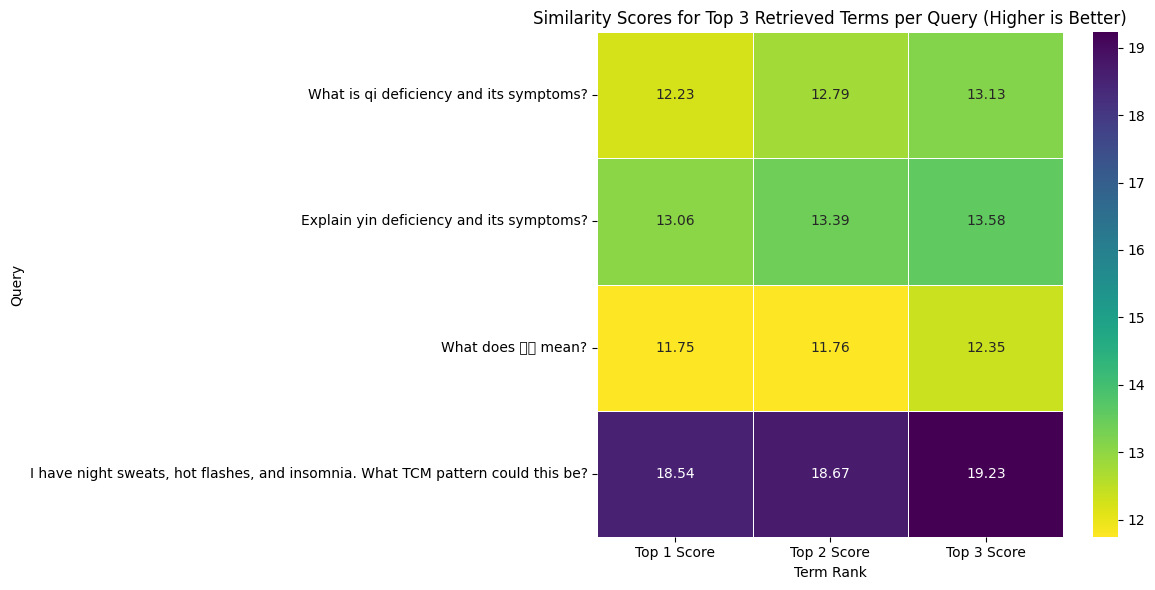


✅ Visualizations complete!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set font to support Chinese characters, as some query titles might contain them
try:
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
except:
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans'] # Fallback if Arial Unicode MS is not found
plt.rcParams['axes.unicode_minus'] = False # This is to prevent minus signs from being displayed as squares

print("\n" + "=" * 80)
print("📊 Visualization of Similarity Scores 📊")
print("=" * 80)

# 1. Display the summary table of similarity scores
print("\nSummary Table of Retrieved Term Similarity Scores:")
print(similarity_df.to_string(index=False))

# 2. Create a heatmap for similarity scores for Top 3 Retrieved Terms per Query

# Prepare data for heatmap: Queries as index, Top N scores as columns
heatmap_data_per_query = pd.DataFrame({
    'Query': similarity_df['query'],
    'Top 1 Score': similarity_df['term_1_score'],
    'Top 2 Score': similarity_df['term_2_score'],
    'Top 3 Score': similarity_df['term_3_score']
})

# Make the query the index for the heatmap
heatmap_pivot = heatmap_data_per_query.set_index('Query')

plt.figure(figsize=(12, len(sample_queries) * 1.5)) # Adjust figure size dynamically
sns.heatmap(heatmap_pivot, annot=True, cmap='viridis_r', fmt=".2f", linewidths=.5)
plt.title('Similarity Scores for Top 3 Retrieved Terms per Query (Higher is Better)')
plt.ylabel('Query')
plt.xlabel('Term Rank')
plt.xticks(rotation=0) # Rotate x-axis labels if necessary
plt.yticks(rotation=0) # Rotate y-axis labels if necessary
plt.tight_layout()
plt.show()

print("\n✅ Visualizations complete!")

## Implement Response Comparison Logic
* Comparing F1 score's Visually


✨ Starting Full Model Evaluation Across All Queries ✨

--- Evaluating for Query: 'What is qi deficiency and its symptoms?' ---
  llama3.2:latest: TP=6, FP=10, FN=12, P=0.38, R=0.33, F1=0.35
  deepseek-r1:latest: TP=9, FP=10, FN=9, P=0.47, R=0.50, F1=0.49
  gpt-oss:latest: TP=9, FP=7, FN=9, P=0.56, R=0.50, F1=0.53
  gemma:latest: TP=8, FP=0, FN=10, P=1.00, R=0.44, F1=0.62
  yi:latest: TP=9, FP=6, FN=9, P=0.60, R=0.50, F1=0.55

--- Evaluating for Query: 'Explain yin deficiency and its symptoms?' ---
  llama3.2:latest: TP=17, FP=0, FN=7, P=1.00, R=0.71, F1=0.83
  deepseek-r1:latest: TP=15, FP=44, FN=9, P=0.25, R=0.62, F1=0.36
  gpt-oss:latest: TP=15, FP=11, FN=9, P=0.58, R=0.62, F1=0.60
  gemma:latest: TP=15, FP=0, FN=9, P=1.00, R=0.62, F1=0.77
  yi:latest: TP=16, FP=3, FN=8, P=0.84, R=0.67, F1=0.74

--- Evaluating for Query: 'What does 气虚 mean?' ---
  llama3.2:latest: TP=7, FP=0, FN=9, P=1.00, R=0.44, F1=0.61
  deepseek-r1:latest: TP=11, FP=7, FN=5, P=0.61, R=0.69, F1=0.65
  gpt-oss:lat

/tmp/ipython-input-2270181215.py:153: UserWarning: Glyph 27668 (\N{CJK UNIFIED IDEOGRAPH-6C14}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2270181215.py:153: UserWarning: Glyph 34394 (\N{CJK UNIFIED IDEOGRAPH-865A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27668 (\N{CJK UNIFIED IDEOGRAPH-6C14}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 34394 (\N{CJK UNIFIED IDEOGRAPH-865A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


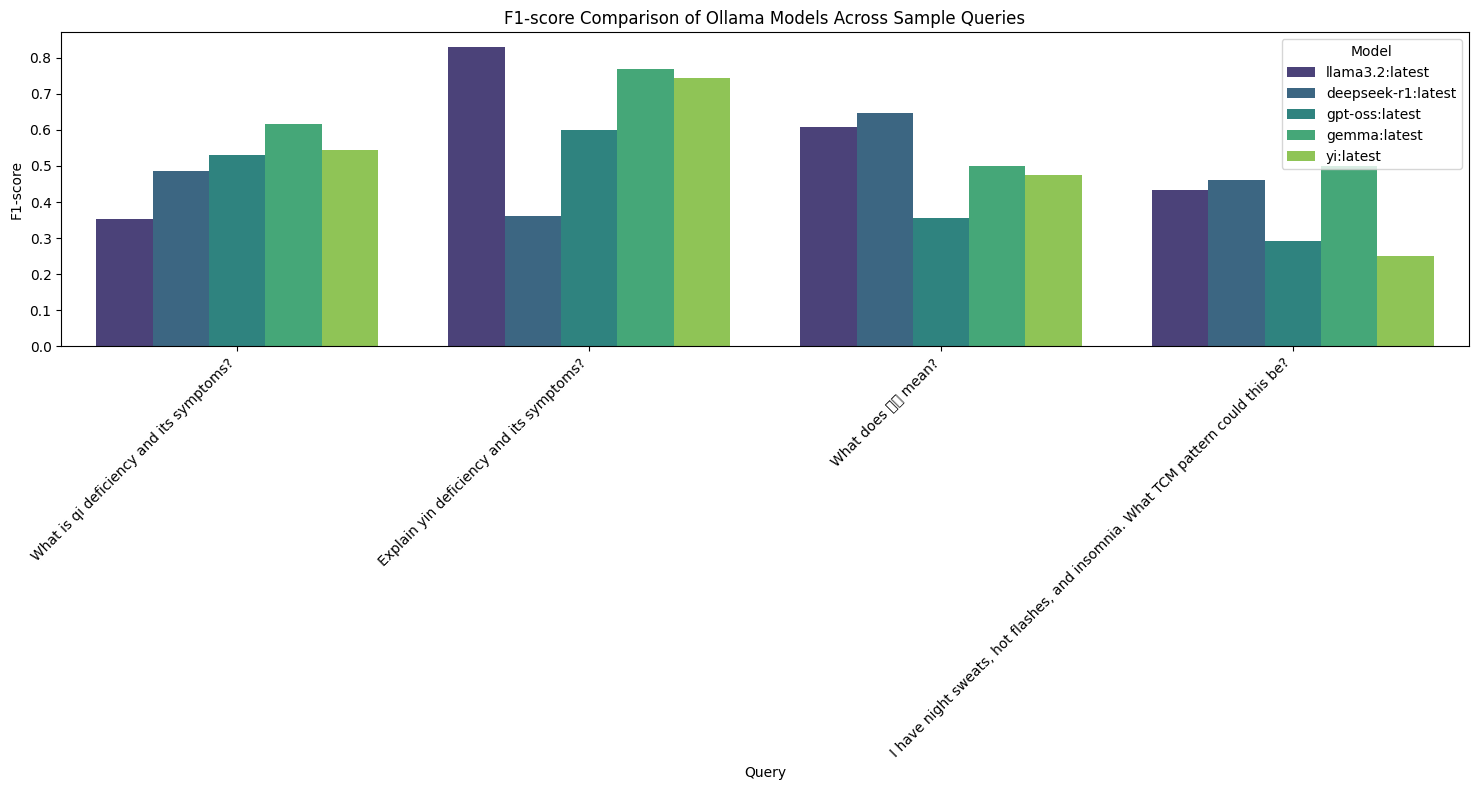


✅ Evaluation metrics table and F1-score visualization complete.


In [ ]:
# Define helper function and data for evaluation
if 'df_clean' in globals():
    flat_tcm_terms_list = df_clean['SimplifiedName'].dropna().tolist()
else:
    flat_tcm_terms_list = []

def evaluate_response_quality(response, ground_truth, all_terms):
    """
    Evaluates the response against ground truth to calculate TP, FP, FN.
    """
    response = response.lower()

    # Combine expected terms and keywords
    expected = set([t.lower() for t in ground_truth.get('expected_tcm_terms', []) + ground_truth.get('expected_keywords', [])])

    # True Positives (TP): Count of expected items found in response
    tp = sum(1 for t in expected if t in response)

    # False Negatives (FN): Count of expected items NOT found
    fn = len(expected) - tp

    # False Positives (FP): Count of other TCM terms found but not expected
    # We check against 'all_terms' (universe of TCM terms) excluding expected ones
    fp = 0
    # Optimize: Check a subset or use set operations if possible, but substring matching is needed.
    # Limit loop for performance if needed, but ~9k is acceptable.
    for term in all_terms:
        term = str(term).lower()
        if len(term) > 1 and term in response:
            # If the term is found, check if it's covered by expected terms
            is_expected = False
            for exp in expected:
                if term in exp or exp in term:
                    is_expected = True
                    break
            if not is_expected:
                fp += 1

    return {'TP': tp, 'FP': fp, 'FN': fn}

# Extend ground_truth_data for all sample_queries for comprehensive evaluation
all_ground_truth_data = {
    sample_queries[0]: {
        'expected_tcm_terms': [
            'qi deficiency', '气虚', 'qì xū',
            'qi deficiency pattern/ syndrome', '气虚证', 'qì xū zhèng',
            'dual deficiency of qi and blood', '气血两虚', 'qì xuè liǎng xū'
        ],
        'expected_keywords': [
            'decreased qi', 'diminished function of internal organs',
            'shortness of breath', 'lassitude', 'listlessness',
            'spontaneous sweating', 'pale tongue', 'weak pulse', 'fatigue'
        ]
    },
    sample_queries[1]: {
        'expected_tcm_terms': [
            'yin deficiency', '阴虚', 'yīn xū',
            'yin deficiency pattern/ syndrome', '阴虚证', 'yīn xū zhèng',
            'dual deficiency of yin and yang', '阴阳两虚证', 'yīn yáng liǎng xū zhèng'
        ],
        'expected_keywords': [
            'depleted yin fluids', 'relative hyperactivity of yang', 'emaciation',
            'dizziness', 'tinnitus', 'dry mouth', 'throat', 'constipation', 'dark-colored urine',
            'afternoon fever', 'malar flush', 'night sweats', 'reddened tongue', 'scanty coating',
            'rapid fine pulse'
        ]
    },
    sample_queries[2]: {
        'expected_tcm_terms': [
            'qi deficiency', '气虚', 'qì xū'
        ],
        'expected_keywords': [
            'vital energy', 'insufficient', 'depleted', 'fatigue', 'weakness', 'lassitude',
            'shortness of breath', 'pale complexion', 'sweating', 'poor digestion', 'low voice',
            'dizziness', 'immunity'
        ]
    },
    sample_queries[3]: {
        'expected_tcm_terms': [
            'yin deficiency and internal heat', '阴虚内热证', 'yīn xū nèi rè zhèng',
            'heat entering ying-blood', '热入营血证', 'rè rù yíng xuè zhèng',
            'yang brightness meridian pattern/ syndrome', '阳明经证', 'yáng míng jīng zhèng'
        ],
        'expected_keywords': [
            'night sweats', 'hot flashes', 'insomnia', 'internal heat', 'low-grade fever',
            'afternoon tidal fever', 'vexing insomnia', 'impaired consciousness', 'flushing'
        ]
    }
}

# Initialize a data structure to store all evaluation results
all_evaluation_results = []

print("\n" + "=" * 80)
print("✨ Starting Full Model Evaluation Across All Queries ✨")
print("=" * 80)

for query_text in sample_queries:
    print(f"\n--- Evaluating for Query: '{query_text}' ---")
    ground_truth_for_query = all_ground_truth_data.get(query_text, {})

    if not ground_truth_for_query:
        print(f"  Warning: No ground truth data defined for query: '{query_text}'. Skipping evaluation.")
        continue

    for model_name in ollama_models:
        response_text = model_responses[query_text].get(model_name, "")
        if not response_text:
            print(f"  No response found for {model_name} on query '{query_text}'.")
            continue

        results = evaluate_response_quality(response_text, ground_truth_for_query, flat_tcm_terms_list)

        tp = results['TP']
        fp = results['FP']
        fn = results['FN']

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        all_evaluation_results.append({
            'Query': query_text,
            'Model': model_name,
            'TP': tp,
            'FP': fp,
            'FN': fn,
            'Precision': precision,
            'Recall': recall,
            'F1-score': f1_score
        })
        print(f"  {model_name}: TP={tp}, FP={fp}, FN={fn}, P={precision:.2f}, R={recall:.2f}, F1={f1_score:.2f}")

print("\n" + "=" * 80)
print("✅ Full Model Evaluation Complete!")
print("=" * 80)

# Convert results to DataFrame for better presentation
evaluation_df = pd.DataFrame(all_evaluation_results)

# Display the summary table
print("\nSummary of Evaluation Metrics:")
print(evaluation_df.round(2).to_string(index=False))

# Visualize F1-scores for all models across all queries
plt.figure(figsize=(15, 8))
sns.barplot(data=evaluation_df, x='Query', y='F1-score', hue='Model', palette='viridis')
plt.title('F1-score Comparison of Ollama Models Across Sample Queries')
plt.xlabel('Query')
plt.ylabel('F1-score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model')
plt.tight_layout()
plt.show()

print("\n✅ Evaluation metrics table and F1-score visualization complete.")


📊 Average Metric Scores by Model 📊
             Model  Accuracy  Precision  Recall  F1-score
deepseek-r1:latest     0.330      0.522   0.536     0.489
      gemma:latest     0.434      0.938   0.444     0.596
    gpt-oss:latest     0.294      0.412   0.503     0.444
   llama3.2:latest     0.409      0.844   0.439     0.556
         yi:latest     0.356      0.736   0.411     0.504


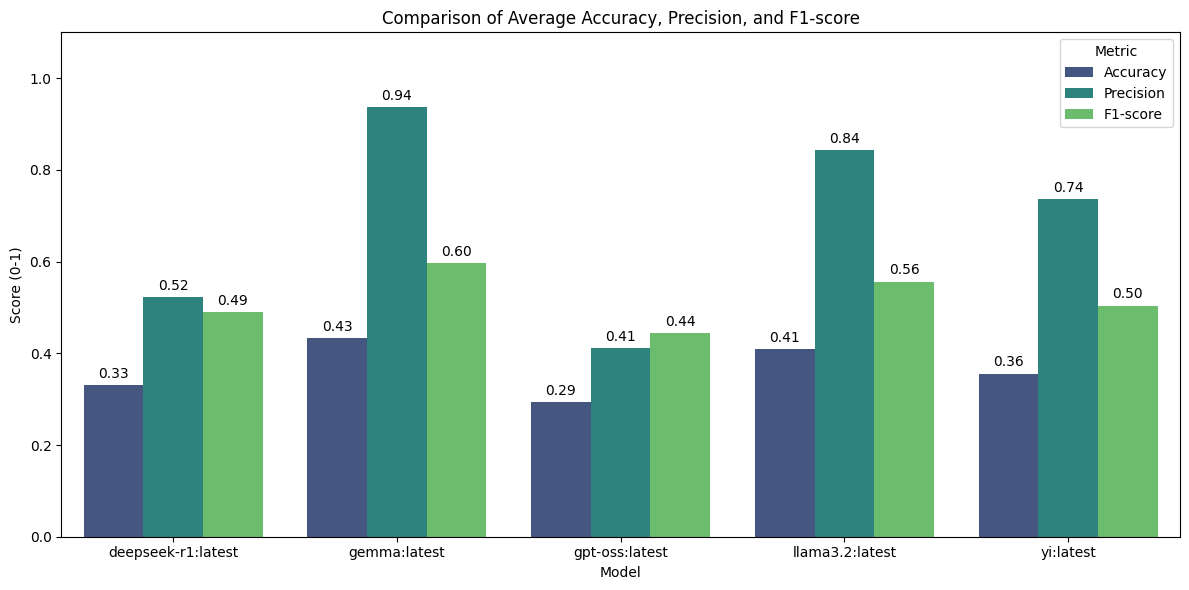

In [ ]:
# Calculate Accuracy (Jaccard Index proxy: TP / (TP + FP + FN)) for each row
# This serves as a strict accuracy measure for extraction tasks where True Negatives are undefined
evaluation_df['Accuracy'] = evaluation_df.apply(
    lambda row: row['TP'] / (row['TP'] + row['FP'] + row['FN']) if (row['TP'] + row['FP'] + row['FN']) > 0 else 0,
    axis=1
)

# Calculate average metrics per model
metrics_of_interest = ['Accuracy', 'Precision', 'Recall', 'F1-score']
average_metrics = evaluation_df.groupby('Model')[metrics_of_interest].mean().reset_index()

print("\n" + "=" * 80)
print("📊 Average Metric Scores by Model 📊")
print("=" * 80)
print(average_metrics.round(3).to_string(index=False))

# Reshape data for grouped bar plot visualization
metrics_melted = average_metrics.melt(
    id_vars='Model',
    value_vars=['Accuracy', 'Precision', 'F1-score'],
    var_name='Metric',
    value_name='Score'
)

# Visualize Comparison
plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_melted, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title('Comparison of Average Accuracy, Precision, and F1-score')
plt.xlabel('Model')
plt.ylabel('Score (0-1)')
plt.ylim(0, 1.1)  # Extend limit slightly for labels
plt.legend(title='Metric', loc='upper right')

# Add value labels on top of bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()